In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import joblib
import os

vessel_df = pd.read_parquet('data/processed/vessel_features_01_01.parquet')
print(f"Loaded: {vessel_df.shape}")
print(vessel_df.head(3))

Loaded: (13515, 20)
        mmsi  sog_mean  sog_max  sog_std  cog_change_mean  cog_change_max  \
0  103669999       0.0      0.0      0.0        39.100000           117.3   
1  123456789       0.0      0.0      0.0        24.843077           148.8   
2  155017179       0.0      0.0      0.0         2.786154            90.8   

   time_gap_mean  time_gap_max  ais_dark_count  anchored_moving  \
0      22.000000     39.000000               0                0   
1       3.692308     21.000000               0                0   
2       3.692308     24.016667               0                0   

   moored_moving  flag_missing_imo  flag_missing_draft  flag_missing_status  \
0              0                 1                   1                    0   
1              0                 1                   1                    0   
2              0                 1                   1                    0   

   identity_completeness  broadcast_count  vessel_type vessel_name   latitude  \
0   

In [3]:
feature_cols = [
    'sog_mean',
    'sog_max',
    'sog_std',
    'cog_change_mean',
    'cog_change_max',
    'time_gap_mean',
    'time_gap_max',
    'ais_dark_count',
    'anchored_moving',
    'moored_moving',
    'flag_missing_imo',
    'flag_missing_draft',
    'flag_missing_status',
    'identity_completeness',
    'broadcast_count',
]

X = vessel_df[feature_cols].copy()

# Confirm no nulls
print(f"Nulls in feature matrix: {X.isnull().sum().sum()}")
print(f"Feature matrix shape: {X.shape}")

Nulls in feature matrix: 0
Feature matrix shape: (13515, 15)


In [5]:
# Scale features (important for Isolation Forest)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Isolation Forest
# contamination=0.05 means we expect ~5% of vessels to be anomalous
model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1        # use all CPU cores
)

model.fit(X_scaled)
print("Model trained.")

Model trained.


In [7]:
# -1 = anomaly, 1 = normal
vessel_df['anomaly_label'] = model.predict(X_scaled)

# Raw score: more negative = more anomalous
vessel_df['anomaly_score'] = model.decision_function(X_scaled)

# How many flagged?
n_anomalies = (vessel_df['anomaly_label'] == -1).sum()
n_total = len(vessel_df)

print(f"Total vessels:     {n_total:,}")
print(f"Flagged anomalies: {n_anomalies:,}")
print(f"Anomaly rate:      {n_anomalies/n_total*100:.1f}%")

Total vessels:     13,515
Flagged anomalies: 676
Anomaly rate:      5.0%


In [9]:
top_anomalies = (
    vessel_df[vessel_df['anomaly_label'] == -1]
    .sort_values('anomaly_score', ascending=True)  # most negative = worst
    .head(20)
    [[
        'mmsi', 'vessel_name', 'vessel_type', 'anomaly_score',
        'ais_dark_count', 'sog_max', 'cog_change_max',
        'identity_completeness', 'anchored_moving', 'moored_moving'
    ]]
)

print("Top 20 most anomalous vessels:")
print(top_anomalies.to_string())

Top 20 most anomalous vessels:
            mmsi         vessel_name  vessel_type  anomaly_score  ais_dark_count  sog_max  cog_change_max  identity_completeness  anchored_moving  moored_moving
12112  368381310           CRESPILOT         50.0      -0.159566               1     32.8           179.2                    0.6                0             66
6607   367390070              LANA K         60.0      -0.149164               1     20.5           175.4                    0.6                0              0
10703  368207090     CAPT. BOB MOORE         50.0      -0.134376               1     27.3           172.5                    0.8                0              0
1377   316056288                   0         37.0      -0.125945               0     31.1           101.7                    0.2                0              0
10953  368235660             DARAH B         60.0      -0.121618               1     18.2           169.1                    0.8                0              0
278

In [11]:
os.makedirs('models', exist_ok=True)

# Save model and scaler
joblib.dump(model, 'models/isolation_forest.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

# Save scored vessel data
vessel_df.to_parquet('data/processed/vessel_scores_01_01.parquet', index=False)

print("Model saved to models/isolation_forest.pkl")
print("Scores saved to data/processed/vessel_scores_01_01.parquet")


Model saved to models/isolation_forest.pkl
Scores saved to data/processed/vessel_scores_01_01.parquet


In [13]:
# For each top anomaly, print a human-readable explanation
def explain_vessel(row):
    reasons = []
    if row['ais_dark_count'] > 0:
        reasons.append(f"went AIS-dark {int(row['ais_dark_count'])} time(s)")
    if row['sog_max'] > 25:
        reasons.append(f"unusually high speed ({row['sog_max']:.1f} kts)")
    if row['cog_change_max'] > 150:
        reasons.append(f"extreme course change ({row['cog_change_max']:.1f} deg)")
    if row['identity_completeness'] < 0.4:
        reasons.append(f"low identity score ({row['identity_completeness']:.2f})")
    if row['moored_moving'] > 0:
        reasons.append(f"moored but moving ({int(row['moored_moving'])} times)")
    if row['anchored_moving'] > 0:
        reasons.append(f"anchored but moving ({int(row['anchored_moving'])} times)")
    if not reasons:
        reasons.append("combination of subtle signals")
    return ' | '.join(reasons)

top_anomalies['explanation'] = top_anomalies.apply(explain_vessel, axis=1)

print("Vessel anomaly explanations:\n")
for _, row in top_anomalies.head(10).iterrows():
    print(f"  {row['vessel_name']:<20} → {row['explanation']}")

Vessel anomaly explanations:

  CRESPILOT            → went AIS-dark 1 time(s) | unusually high speed (32.8 kts) | extreme course change (179.2 deg) | moored but moving (66 times)
  LANA K               → went AIS-dark 1 time(s) | extreme course change (175.4 deg)
  CAPT. BOB MOORE      → went AIS-dark 1 time(s) | unusually high speed (27.3 kts) | extreme course change (172.5 deg)
  0                    → unusually high speed (31.1 kts) | low identity score (0.20)
  DARAH B              → went AIS-dark 1 time(s) | extreme course change (169.1 deg)
  HERE WE GO           → went AIS-dark 1 time(s)
  MISSISSIPPI DELTA    → went AIS-dark 1 time(s) | unusually high speed (26.8 kts) | extreme course change (179.6 deg)
  LYLA ANGELLE         → went AIS-dark 1 time(s) | moored but moving (50 times)
  CATALINA EXPRESS     → went AIS-dark 1 time(s) | unusually high speed (29.5 kts) | extreme course change (174.5 deg)
  CATALINA JET         → went AIS-dark 1 time(s) | unusually high speed (30.1 k

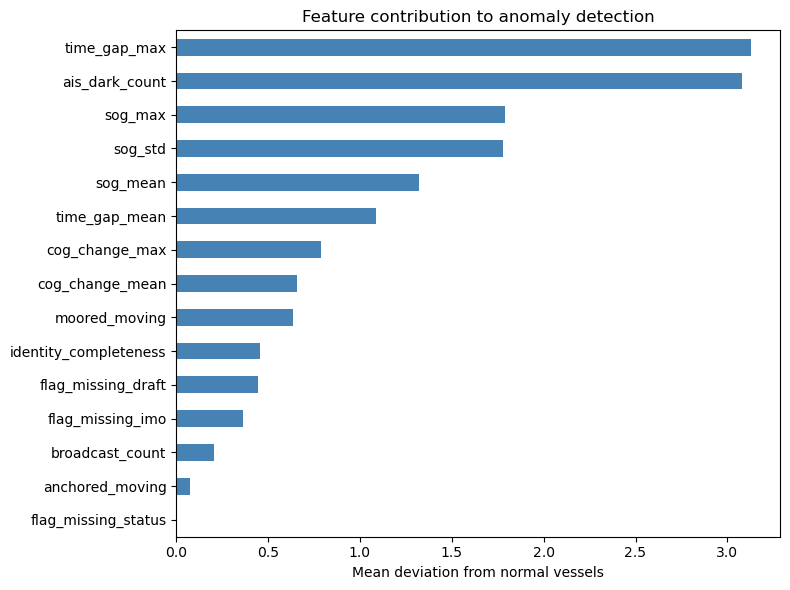

Plot saved.


In [15]:
import matplotlib.pyplot as plt

# Calculate mean absolute feature contribution across anomalous vessels
anomaly_profiles = pd.DataFrame(
    X_scaled[(vessel_df['anomaly_label'] == -1)],
    columns=feature_cols
)
normal_profiles = pd.DataFrame(
    X_scaled[(vessel_df['anomaly_label'] == 1)],
    columns=feature_cols
)

# Difference between anomaly and normal mean = what stands out
diff = anomaly_profiles.mean() - normal_profiles.mean()
diff_sorted = diff.abs().sort_values(ascending=True)

plt.figure(figsize=(8, 6))
diff_sorted.plot(kind='barh', color='steelblue')
plt.xlabel('Mean deviation from normal vessels')
plt.title('Feature contribution to anomaly detection')
plt.tight_layout()
plt.savefig('data/processed/feature_importance.png', dpi=150)
plt.show()
print("Plot saved.")